<a href="https://colab.research.google.com/github/nikikiriki/dotfiles/blob/master/Kopie_von_2214Intro_ML_recap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

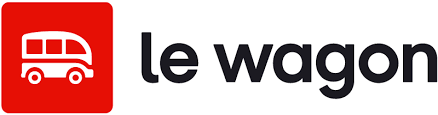

In [ ]:
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Predicting customer churn in a bank thank to Machine Learning.


We will work on the dataset available on Kaggle [here](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction). Download the dataset and add it to your Google Colab.

## Data exploration

Open the csv with Pandas and start by exploring the data.
How many lines ?
How many columns ?
What type of data ?

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("Churn_Modelling.csv")

In [ ]:
df.info()
df.shape, df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


((10000, 14),
 RowNumber          0
 CustomerId         0
 Surname            0
 CreditScore        0
 Geography          0
 Gender             0
 Age                0
 Tenure             0
 Balance            0
 NumOfProducts      0
 HasCrCard          0
 IsActiveMember     0
 EstimatedSalary    0
 Exited             0
 dtype: int64)

Our goal is to predict if a customer will churn.


What type of task will you be working on ?

In [ ]:
#Classification (because our target (churn) is categorical )
#churn = yes/no ; 1/0

Which columns will you use as X ? Which columns will you use as y ? Create X and y.

In [ ]:
df.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
y = df["Exited"]


In [ ]:
X = df[['CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary']]
#you could also here exclude certain columns with .drop()

In [ ]:
type(y) #should be Series
type(X) #should be DF

pandas.core.frame.DataFrame

Create a train / test split before continuing.

In [ ]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y)

In [ ]:
Xtrain.shape, Xtest.shape, ytrain.shape, ytest.shape

((7500, 11), (2500, 11), (7500,), (2500,))

## Prepare the data

In [ ]:
X_num_columns = X.select_dtypes(include="number").columns
X_cat_columns = X.select_dtypes(exclude="number").columns
X_num_columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

Select the numerical columns and normalize them. Apply the transformation only on X_train.

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")

In [ ]:
X_train_num_preprocessed = scaler.fit_transform(Xtrain[X_num_columns])

In [ ]:
X_test_num_preprocessed =  scaler.transform(Xtest[X_num_columns])
#scaler.transform(Xtest[['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard','IsActiveMember', 'EstimatedSalary', 'Exited']])

Select the non-numerical columns and transform them into numerical data. Apply the transformation only on X_train.

In [ ]:
ohe = OneHotEncoder(sparse_output=False, drop="if_binary").set_output(transform = "pandas")

In [ ]:
Xtrain_cat_preprocessed = ohe.fit_transform(Xtrain[X_cat_columns])

In [ ]:
Xtest_cat_preprocessed = ohe.transform(Xtest[X_cat_columns])

Now the last step here remaining is concactenting the 2 dataframes back together

In [ ]:
Xtrain_preprocessed = pd.concat([X_train_num_preprocessed, Xtrain_cat_preprocessed], axis=1)
Xtest_preprocessed = pd.concat([X_test_num_preprocessed, Xtest_cat_preprocessed], axis=1)

## Create your ML model

Select the right model according to the task and train it on the appropriate data.

In [ ]:
#classification
model = LogisticRegression()

In [ ]:
model.fit(Xtrain_preprocessed, ytrain)

LogisticRegression()

## Score your model

We now want to see if our model can generalize on other data.
Prepare your X_test accordingly and score your model.

In [ ]:
model.score(Xtest_preprocessed, ytest)
#accuracy how many (%) predictions were correct.
#even though it would be painful to admit and sad, we have to admit that 100% accuracy indicvates that something is off...

#after removing the target from the feature matrix, our accuracy dropped to 82%

0.818

In [ ]:
ytest.value_counts(normalize=True)

,proportion
Exited,
0,0.806
1,0.194


In [ ]:
model.predict(Xtest_preprocessed)[:20]

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
ytest[:20]

,Exited
6272,1
6449,1
3699,0
8516,0
5942,1
3245,1
5346,0
9067,0
3678,0
9659,0


In [ ]:
#accuracy should never be the only metric based on which you assess classifier performance!
#you might get 99% accuracy for a classifier (99% of predictions are correct), but id say the model is VERY bad.
#how is that possible?


In [ ]:
#output = 1
#999 healthy people (1), 1 sick person (0)
#99.9%

In [ ]:
#1000 (1); 9000 (0)
#if you have a model that always says 0, you will have 90% accuracy

In [ ]:
#70-30 imbalance is the largest that is still ok

#imbalance=True;
#downsample the majority clas

In [ ]:
df["Exited"].value_counts()

,count
Exited,
0,7963
1,2037


In [ ]:
df[df["Exited"]== 1]

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
16,17,15737452,Romeo,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,9982,15672754,Burbidge,498,Germany,Male,42,3,152039.70,1,1,1,53445.17,1
9982,9983,15768163,Griffin,655,Germany,Female,46,7,137145.12,1,1,0,115146.40,1
9991,9992,15769959,Ajuluchukwu,597,France,Female,53,4,88381.21,1,1,0,69384.71,1
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [ ]:
downsampled_dataset = pd.concat([df[df["Exited"]== 1], df[df["Exited"]== 0].sample(2500)])
downsampled_dataset["Exited"].value_counts(normalize=True)

,proportion
Exited,
0,0.551025
1,0.448975
